<a href="https://colab.research.google.com/github/Rachana-AC/ML-Lab/blob/main/Triple_Exponential_Smoothing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# First 36 months
data = {
    "Month": pd.date_range("2023-01-01", periods=36, freq="MS"),
    "Demand": [
        827, 836, 977, 1065, 1132, 1281,
        1452, 1424, 1270, 1155, 1093, 1011,
        1038, 1105, 1214, 1284, 1468, 1600,
        1806, 1757, 1551, 1418, 1333, 1201,
        1244, 1294, 1458, 1570, 1754, 1942,
        2172, 2077, 1829, 1674, 1552, 1441
    ]
}

df = pd.DataFrame(data)
df.set_index("Month", inplace=True)

# -----------------------------
# ADDITIVE MODEL
# -----------------------------
additive_model = ExponentialSmoothing(
    df["Demand"],
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
)

additive_fit = additive_model.fit(optimized=True)

additive_forecast = additive_fit.forecast(6)


# -----------------------------
# MULTIPLICATIVE MODEL
# -----------------------------
multiplicative_model = ExponentialSmoothing(
    df["Demand"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12,
    initialization_method="estimated"
)

multiplicative_fit = multiplicative_model.fit(optimized=True)

multiplicative_forecast = multiplicative_fit.forecast(6)


# -----------------------------
# COMBINED FORECAST TABLE
# -----------------------------
forecast_table = pd.DataFrame({
    "Month": additive_forecast.index,
    "Additive_Forecast": additive_forecast.values,
    "Multiplicative_Forecast": multiplicative_forecast.values
})

forecast_table["Additive_Forecast"] = \
    forecast_table["Additive_Forecast"].round(2)

forecast_table["Multiplicative_Forecast"] = \
    forecast_table["Multiplicative_Forecast"].round(2)

print(forecast_table)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


       Month  Additive_Forecast  Multiplicative_Forecast
0 2026-01-01            1453.92                  1475.63
1 2026-02-01            1482.37                  1530.56
2 2026-03-01            1606.71                  1715.15
3 2026-04-01            1682.96                  1832.80
4 2026-05-01            1814.08                  2032.93
5 2026-06-01            1956.44                  2239.84


In [11]:
# ============================================================
# TRIPLE EXPONENTIAL SMOOTHING
# ADDITIVE vs MULTIPLICATIVE
# 36 MONTHS TRAINING + 6 MONTHS TESTING
# ============================================================

import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. ENTER THE COMPLETE DATASET
# ============================================================

data = {
    "Month": [
        "2023-01-01", "2023-02-01", "2023-03-01", "2023-04-01",
        "2023-05-01", "2023-06-01", "2023-07-01", "2023-08-01",
        "2023-09-01", "2023-10-01", "2023-11-01", "2023-12-01",

        "2024-01-01", "2024-02-01", "2024-03-01", "2024-04-01",
        "2024-05-01", "2024-06-01", "2024-07-01", "2024-08-01",
        "2024-09-01", "2024-10-01", "2024-11-01", "2024-12-01",

        "2025-01-01", "2025-02-01", "2025-03-01", "2025-04-01",
        "2025-05-01", "2025-06-01", "2025-07-01", "2025-08-01",
        "2025-09-01", "2025-10-01", "2025-11-01", "2025-12-01",

        "2026-01-01", "2026-02-01", "2026-03-01", "2026-04-01",
        "2026-05-01", "2026-06-01"
    ],

    "Demand": [
        827, 836, 977, 1065, 1132, 1281,
        1452, 1424, 1270, 1155, 1093, 1011,

        1038, 1105, 1214, 1284, 1468, 1600,
        1806, 1757, 1551, 1418, 1333, 1201,

        1244, 1294, 1458, 1570, 1754, 1942,
        2172, 2077, 1829, 1674, 1552, 1441,

        1467, 1505, 1671, 1835, 2047, 2256
    ]
}


# ============================================================
# 2. CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(data)

df["Month"] = pd.to_datetime(df["Month"])

df.set_index("Month", inplace=True)

# Set monthly frequency
df = df.asfreq("MS")


# ============================================================
# 3. SPLIT DATA
# ============================================================

# First 36 months = Training
train = df.iloc[:36]

# Last 6 months = Testing
test = df.iloc[36:]


print("Number of training observations:", len(train))
print("Number of test observations:", len(test))

print("\nTraining Period:")
print(train.index[0], "to", train.index[-1])

print("\nTesting Period:")
print(test.index[0], "to", test.index[-1])


# ============================================================
# 4. ADDITIVE TRIPLE EXPONENTIAL SMOOTHING
# ============================================================

additive_model = ExponentialSmoothing(
    train["Demand"],
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
)

additive_fit = additive_model.fit(
    optimized=True
)

# Forecast next 6 months
additive_forecast = additive_fit.forecast(6)


# ============================================================
# 5. MULTIPLICATIVE TRIPLE EXPONENTIAL SMOOTHING
# ============================================================

multiplicative_model = ExponentialSmoothing(
    train["Demand"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12,
    initialization_method="estimated"
)

multiplicative_fit = multiplicative_model.fit(
    optimized=True
)

# Forecast next 6 months
multiplicative_forecast = multiplicative_fit.forecast(6)


# ============================================================
# 6. CREATE COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    "Month": test.index,
    "Actual_Demand": test["Demand"].values,
    "Additive_Forecast": additive_forecast.values,
    "Multiplicative_Forecast": multiplicative_forecast.values
})


# Round forecast values
comparison["Additive_Forecast"] = \
    comparison["Additive_Forecast"].round(2)

comparison["Multiplicative_Forecast"] = \
    comparison["Multiplicative_Forecast"].round(2)


# ============================================================
# 7. CALCULATE RMSE
# ============================================================

actual = test["Demand"].values

rmse_additive = np.sqrt(
    mean_squared_error(
        actual,
        additive_forecast.values
    )
)

rmse_multiplicative = np.sqrt(
    mean_squared_error(
        actual,
        multiplicative_forecast.values
    )
)


# ============================================================
# 8. CALCULATE MAPE
# ============================================================

mape_additive = np.mean(
    np.abs(
        (actual - additive_forecast.values) / actual
    )
) * 100


mape_multiplicative = np.mean(
    np.abs(
        (actual - multiplicative_forecast.values) / actual
    )
) * 100


# ============================================================
# 9. CREATE MODEL PERFORMANCE TABLE
# ============================================================

performance = pd.DataFrame({
    "Model": [
        "Triple Exponential - Additive",
        "Triple Exponential - Multiplicative"
    ],

    "RMSE": [
        rmse_additive,
        rmse_multiplicative
    ],

    "MAPE (%)": [
        mape_additive,
        mape_multiplicative
    ]
})


performance["RMSE"] = performance["RMSE"].round(2)
performance["MAPE (%)"] = performance["MAPE (%)"].round(2)


# ============================================================
# 10. DISPLAY RESULTS
# ============================================================

print("\n")
print("=" * 75)
print("ACTUAL VS FORECAST VALUES - TEST DATA")
print("=" * 75)

print(comparison.to_string(index=False))


print("\n")
print("=" * 75)
print("MODEL PERFORMANCE")
print("=" * 75)

print(performance.to_string(index=False))

Number of training observations: 36
Number of test observations: 6

Training Period:
2023-01-01 00:00:00 to 2025-12-01 00:00:00

Testing Period:
2026-01-01 00:00:00 to 2026-06-01 00:00:00


ACTUAL VS FORECAST VALUES - TEST DATA
     Month  Actual_Demand  Additive_Forecast  Multiplicative_Forecast
2026-01-01           1467            1453.92                  1475.63
2026-02-01           1505            1482.37                  1530.56
2026-03-01           1671            1606.71                  1715.15
2026-04-01           1835            1682.96                  1832.80
2026-05-01           2047            1814.08                  2032.93
2026-06-01           2256            1956.44                  2239.84


MODEL PERFORMANCE
                              Model   RMSE  MAPE (%)
      Triple Exponential - Additive 169.27      6.53
Triple Exponential - Multiplicative  22.88      1.08


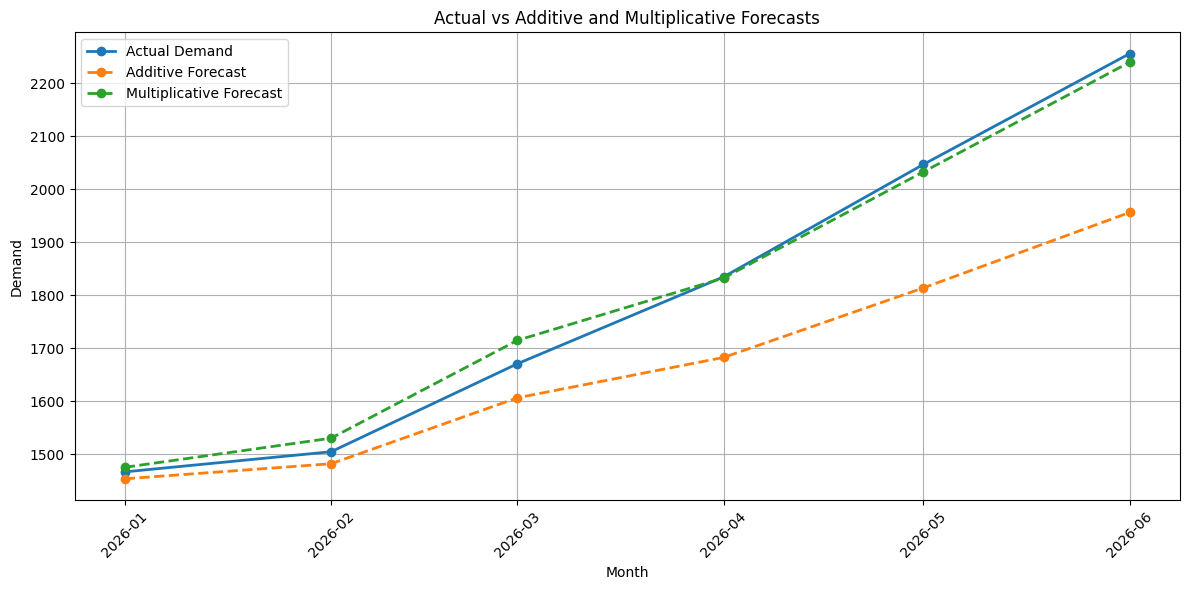

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Actual demand
plt.plot(
    test.index,
    test["Demand"],
    marker="o",
    linewidth=2,
    label="Actual Demand"
)

# Additive forecast
plt.plot(
    test.index,
    additive_forecast,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Additive Forecast"
)

# Multiplicative forecast
plt.plot(
    test.index,
    multiplicative_forecast,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Multiplicative Forecast"
)

plt.title(
    "Actual vs Additive and Multiplicative Forecasts"
)

plt.xlabel("Month")
plt.ylabel("Demand")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

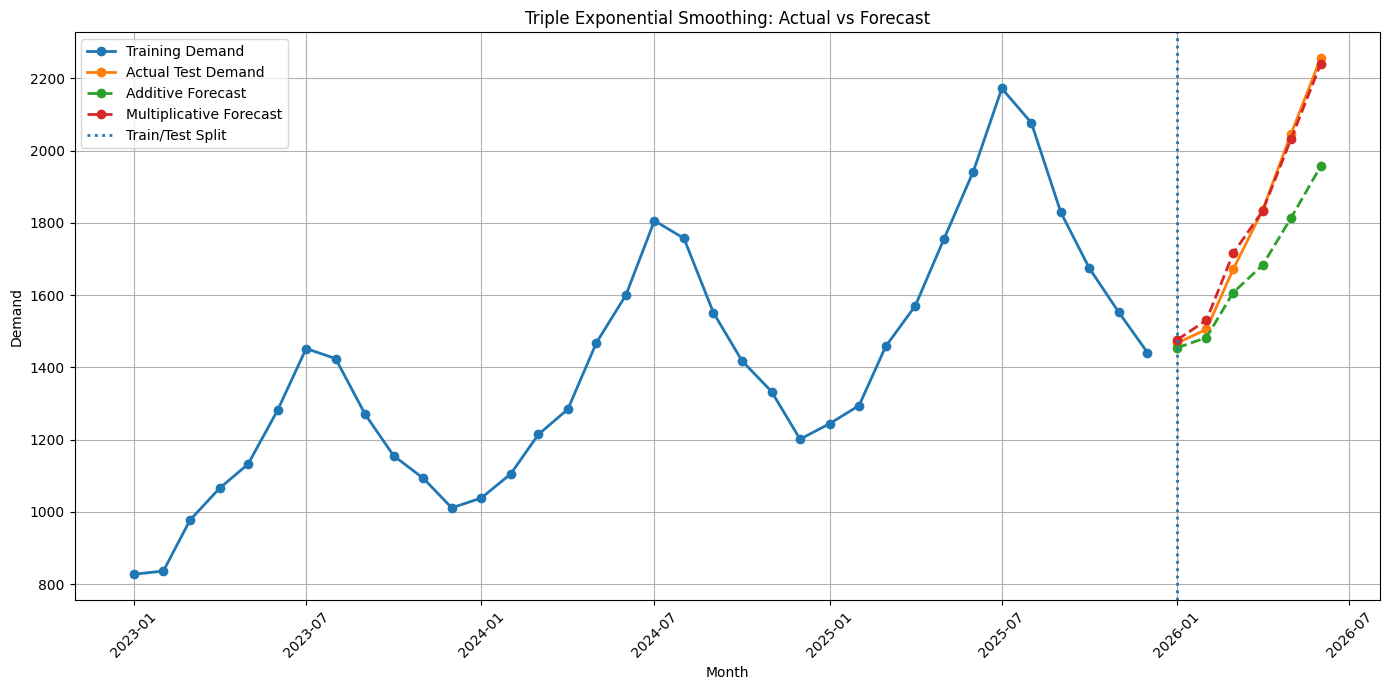

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Training data
plt.plot(
    train.index,
    train["Demand"],
    marker="o",
    linewidth=2,
    label="Training Demand"
)

# Actual test data
plt.plot(
    test.index,
    test["Demand"],
    marker="o",
    linewidth=2,
    label="Actual Test Demand"
)

# Additive forecast
plt.plot(
    test.index,
    additive_forecast,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Additive Forecast"
)

# Multiplicative forecast
plt.plot(
    test.index,
    multiplicative_forecast,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Multiplicative Forecast"
)

# Mark train-test split
plt.axvline(
    x=test.index[0],
    linestyle=":",
    linewidth=2,
    label="Train/Test Split"
)

plt.title(
    "Triple Exponential Smoothing: Actual vs Forecast"
)

plt.xlabel("Month")
plt.ylabel("Demand")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()